In [1]:
#!conda env list

In [2]:
#!conda run -p /home/njm12/ATMS_523/envs/xarray-climate python -m ipykernel install --user --name xarray-climate --display-name "Python (xarray-climate)"

In [3]:
import sys
print(sys.executable)

/home/njm12/ATMS_523/envs/xarray-climate/bin/python


In [4]:
# Cell 1: Imports and environment setup
import os
import glob
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, box
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from shapely.ops import nearest_points
from geopy.distance import geodesic

#Interactive Tool Imports
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"  # or "notebook_connected"

#Statistical Significance Testing Imports
from scipy.stats import kruskal
import itertools

# Allow OGR to accept non-closed rings
os.environ["OGR_GEOMETRY_ACCEPT_UNCLOSED_RING"] = "YES"

# --- Configuration ---
base_dir = "/home/njm12/ATMS_596/ATMS-596-Capstone-Project/Land-Water"
target_crs = "EPSG:26915"  # UTM Zone 15
tornado_csv = "/home/njm12/ATMS_596/1950-2024_actual_tornadoes.csv"  # Update with your CSV path
states_of_interest = ["IL", "IA", "MO"]
min_date = pd.to_datetime("1950-01-01")  # Start from first date in dataset

In [5]:
# Cell 2: Load UMESC Mississippi River shapefiles
pool_dirs = [f"Pool {p}" for p in range(12, 27) if p != 23] + ["Open River", "Open River 2"]
gdfs = []

for pool_dir in pool_dirs:
    if "Open River" in pool_dir:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z16n83.shp"))
        local_crs = "EPSG:26916"
    else:
        shp_files = glob.glob(os.path.join(base_dir, pool_dir, "*z15n83.shp"))
        local_crs = target_crs

    for f in shp_files:
        gdf = gpd.read_file(f)
        if gdf.crs is None:
            gdf = gdf.set_crs(local_crs)
        gdf = gdf.to_crs(target_crs)
        gdf["POOL"] = pool_dir
        gdfs.append(gdf)

umesc_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=target_crs)
print("UMESC combined:", umesc_all.shape)
print(f"Pools included: {sorted(umesc_all['POOL'].unique())}")

ERROR 1: PROJ: proj_create_from_database: Open of /home/njm12/ATMS_523/envs/xarray-climate/share/proj failed


UMESC combined: (8050, 14)
Pools included: ['Open River', 'Open River 2', 'Pool 12', 'Pool 13', 'Pool 14', 'Pool 15', 'Pool 16', 'Pool 17', 'Pool 18', 'Pool 19', 'Pool 20', 'Pool 21', 'Pool 22', 'Pool 24', 'Pool 25', 'Pool 26']


In [6]:
# --- Derive approximate river centerline from UMESC polygons ---
# Fix invalid polygons before union
umesc_all["geometry"] = umesc_all.geometry.make_valid()
umesc_all["geometry"] = umesc_all.buffer(0)  # Ensures clean geometry

# Use the new 'union_all()' method (replaces deprecated unary_union)
river_union = umesc_all.union_all()

# Derive approximate river centerline
river_centerline = gpd.GeoSeries([river_union], crs=target_crs).buffer(-200).boundary
river_centerline = gpd.GeoDataFrame(geometry=river_centerline, crs=target_crs)
print("River centerline constructed from UMESC polygons.")

River centerline constructed from UMESC polygons.


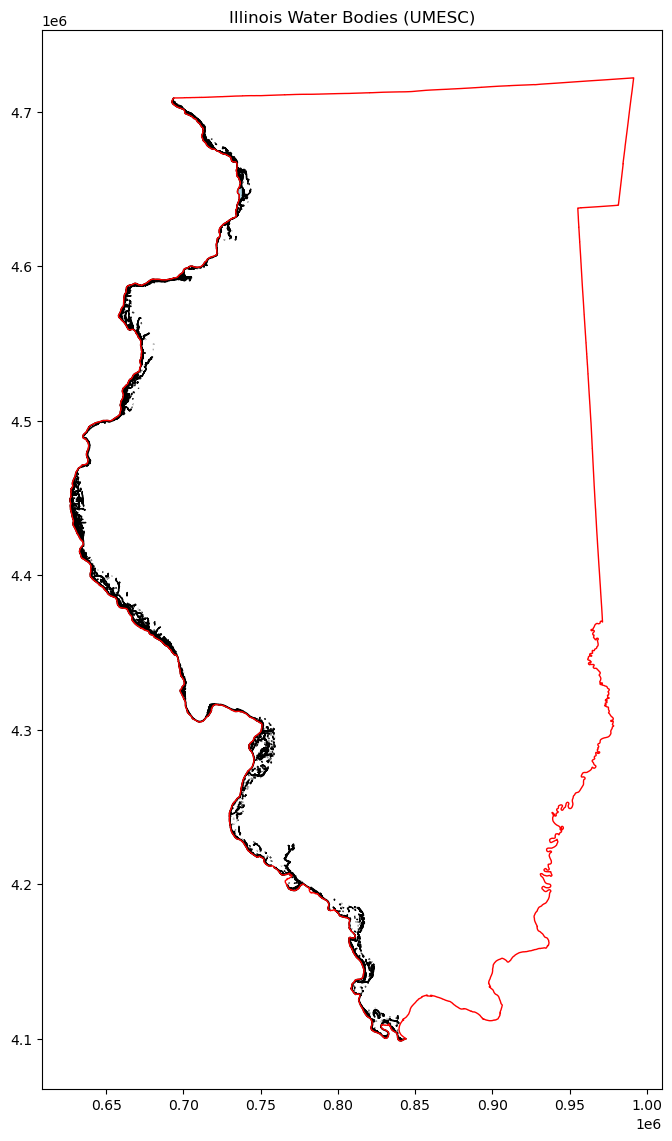

In [7]:
# Cell 3: Extract Illinois water portion
url = "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
states = gpd.read_file(url)
illinois = states[states["NAME"] == "Illinois"].to_crs(target_crs)

# Filter water polygons only
water_only = umesc_all[umesc_all["LAND_WATER"] == "Water"].copy()
water_il = gpd.clip(water_only, illinois)

# Plot check
ax = water_il.plot(figsize=(8, 14), color="lightblue", edgecolor="k")
illinois.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Illinois Water Bodies (UMESC)")
plt.show()

In [8]:
print("Number of invalid geometries in water_only:", (~water_only.is_valid).sum())
print("Invalid geometries indices:", water_only[~water_only.is_valid].index)

Number of invalid geometries in water_only: 0
Invalid geometries indices: Index([], dtype='int64')


In [9]:
# Fix invalid geometries using buffer(0) - only if needed
water_only.loc[~water_only.is_valid, "geometry"] = water_only.loc[~water_only.is_valid, "geometry"].buffer(0)

# Verify
print("Invalid geometries after fix:", (~water_only.is_valid).sum())

Invalid geometries after fix: 0


In [10]:
# Ensure Illinois geometry is valid
illinois["geometry"] = illinois["geometry"].buffer(0)

# Perform clip
water_il = gpd.clip(water_only, illinois)

print("Clipped water shapes:", water_il.shape)

Clipped water shapes: (2876, 14)


In [11]:
# Combine all Illinois water polygons into a single geometry
river_il = water_il.union_all()
print(type(river_il))
print("Bounds of Illinois river section:", river_il.bounds)

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Bounds of Illinois river section: (626594.3664122473, 4098437.22724262, 844182.0029604747, 4708927.272888837)


In [12]:
# Automatic date parsing
tornadoes = pd.read_csv(tornado_csv, parse_dates=['date'])

# Filter by states, EF-scale, and date (can include stronger tornadoes on map, if necessary / min_date will likely be changed)
tornadoes = tornadoes[
    tornadoes['st'].isin(states_of_interest) &
    tornadoes['mag'].isin([0, 1, 2, 3, 4, 5]) &
    (tornadoes['date'] >= min_date)
]

print("Filtered tornadoes:", tornadoes.shape)
tornadoes

Filtered tornadoes: (8287, 29)


,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
6,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,18.80,50,1,1,1,119,117,0,0,0
7,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,18.00,200,1,1,1,119,5,0,0,0
9,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,9.60,50,1,1,1,157,0,0,0,0
11,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,2.30,300,1,1,1,93,0,0,0,0
12,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,0.10,100,1,1,1,91,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71664,624857,2024,8,15,2024-08-15,22:06:00,3,IL,17,0,...,3.20,50,1,1,1,175,0,0,0,0
71687,624880,2024,8,30,2024-08-30,11:45:00,3,IL,17,0,...,0.08,20,1,1,1,157,0,0,0,0
71712,624820,2024,8,5,2024-08-05,20:57:00,3,IA,19,0,...,0.33,30,1,1,1,191,0,0,0,0
71713,624821,2024,8,5,2024-08-05,21:11:00,3,IA,19,0,...,0.98,80,1,1,1,191,0,0,0,0


In [13]:
# Remove any rows with missing or invalid coordinates
coord_cols = ['slon', 'slat', 'elon', 'elat']
tornadoes = tornadoes.dropna(subset=coord_cols)

# Remove out-of-bounds or unrealistic coordinates
tornadoes = tornadoes[
    (tornadoes['slon'].between(-180, 180)) &
    (tornadoes['elon'].between(-180, 180)) &
    (tornadoes['slat'].between(-90, 90)) &
    (tornadoes['elat'].between(-90, 90))
]
print("After coordinate cleaning:", tornadoes.shape)

After coordinate cleaning: (8287, 29)


In [14]:
# --- Fix 1: Convert positive longitudes (U.S. longitudes are negative west of Greenwich) ---
tornadoes['slon'] = tornadoes['slon'].apply(lambda x: -x if x > 0 else x)
tornadoes['elon'] = tornadoes['elon'].apply(lambda x: -x if x > 0 else x)

# --- Fix 2: Remove zero or missing coordinates (invalid positions) ---
tornadoes.loc[tornadoes['slat'] == 0, 'slat'] = np.nan
tornadoes.loc[tornadoes['elat'] == 0, 'elat'] = np.nan
tornadoes.loc[tornadoes['slon'] == 0, 'slon'] = np.nan
tornadoes.loc[tornadoes['elon'] == 0, 'elon'] = np.nan

# Drop rows with NaNs after cleaning
tornadoes = tornadoes.dropna(subset=['slon', 'slat', 'elon', 'elat']).copy()

# Check coordinate ranges again
print("Longitude range (fixed):", tornadoes[['slon', 'elon']].min().min(), "to", tornadoes[['slon', 'elon']].max().max())
print("Latitude range (fixed):", tornadoes[['slat', 'elat']].min().min(), "to", tornadoes[['slat', 'elat']].max().max())

Longitude range (fixed): -96.6 to -85.23
Latitude range (fixed): 36.0022 to 45.5


In [15]:
from shapely.geometry import LineString, Point
import geopandas as gpd

# Create LineString or Point geometries
def make_geom(row):
    if pd.isna(row['elon']) or pd.isna(row['elat']) or \
       (row['elon'] == row['slon'] and row['elat'] == row['slat']):
        return Point(row['slon'], row['slat'])
    else:
        return LineString([(row['slon'], row['slat']), (row['elon'], row['elat'])])

tornadoes['geometry'] = tornadoes.apply(make_geom, axis=1)

# Convert to GeoDataFrame
tornado_gdf = gpd.GeoDataFrame(tornadoes, geometry='geometry', crs="EPSG:4326")

# Reproject to match water shapefile CRS
tornado_gdf = tornado_gdf.to_crs(target_crs)

print("Tornado geometries rebuilt")
print("Geometry types:", tornado_gdf.geometry.geom_type.value_counts())
print("Bounds:", tornado_gdf.total_bounds)

Tornado geometries rebuilt
Geometry types: LineString    4739
Point         1054
Name: count, dtype: int64
Bounds: [ 205367.62901075 3987738.95756939 1160467.39964418 5041734.47457036]


In [16]:
# Fix invalid water polygons
water_il['geometry'] = water_il['geometry'].buffer(0)

# Merge into single geometry
river_il_geom = water_il.geometry.union_all()  # or .union_all() if using new shapely

# Ensure the final geometry is valid
from shapely.validation import make_valid
river_il_geom = make_valid(river_il_geom)

In [17]:
# Buffer by 10 km
river_buffer = river_il_geom.buffer(10000)  # adjust as needed

# Check intersections with buffer
tornado_gdf['crosses_river'] = tornado_gdf.intersects(river_buffer)
crossings = tornado_gdf[tornado_gdf['crosses_river']]

print("Total tornadoes crossing Mississippi River or intersecting buffered zone:", crossings.shape[0])
print("Counts by EF-scale:\n", crossings['mag'].value_counts())

Total tornadoes crossing Mississippi River or intersecting buffered zone: 372
Counts by EF-scale:
 mag
0    124
1    122
2     79
3     37
4     10
Name: count, dtype: int64


In [18]:
#Quick sanity to make sure the river buffer is actually or approximately ~10 km (and in the right units). 

from shapely.ops import nearest_points

# Pick a point on the river geometry
river_point = river_il_geom.representative_point()

# Pick nearest point on the buffer boundary
buffer_boundary = river_buffer.boundary
nearest = nearest_points(river_point, buffer_boundary)[1]

# Compute distance in meters (UTM units)
distance_m = river_point.distance(nearest)
distance_km = distance_m / 1000
print(f"Distance from river to buffer boundary: {distance_km:.2f} km")

Distance from river to buffer boundary: 10.67 km


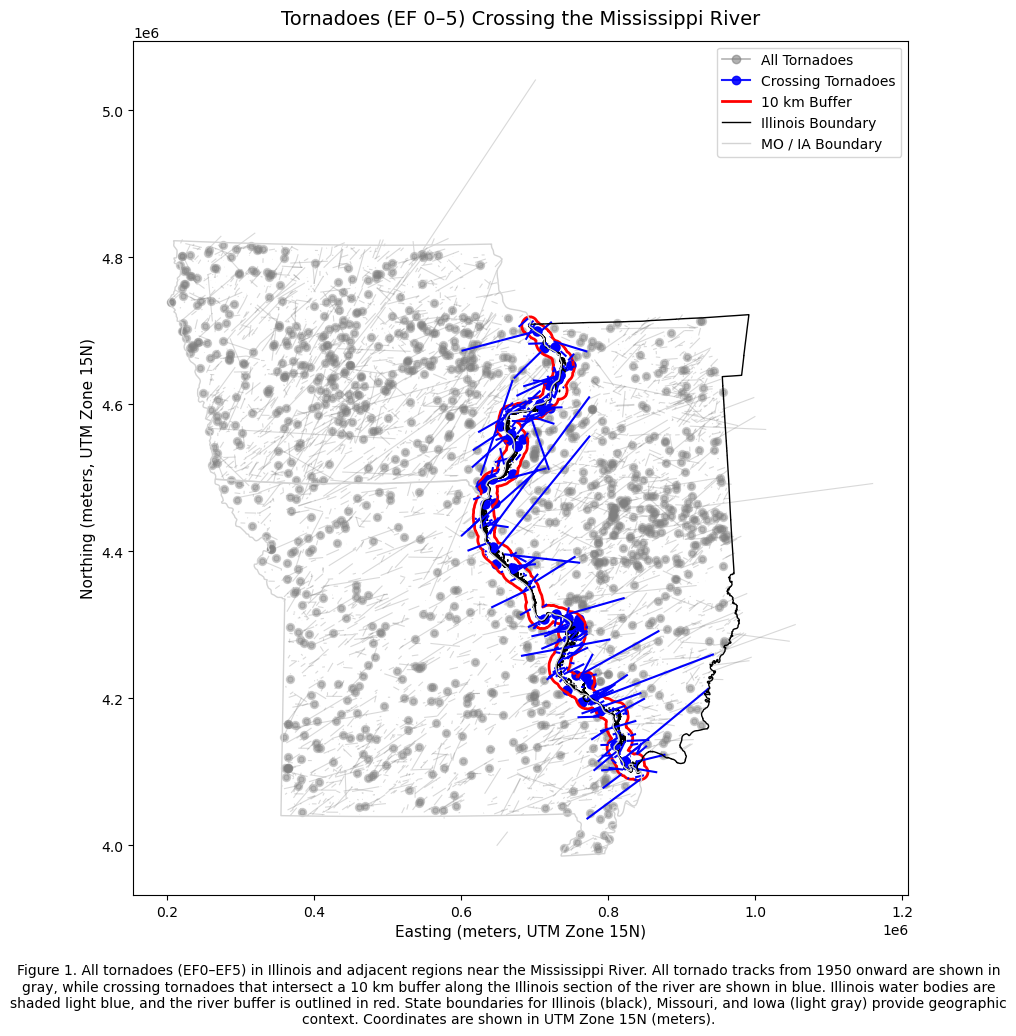

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Step 5: Plot ---
fig, ax = plt.subplots(figsize=(10, 14))

# Plot Illinois water and river buffer
water_il.plot(ax=ax, color='lightblue', edgecolor='k')
gpd.GeoSeries([river_buffer]).boundary.plot(ax=ax, color='red', linewidth=2, label='10 km Buffer')

# Plot all tornadoes (lines + points)
tornado_gdf.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3)
tornado_gdf[tornado_gdf.geometry.geom_type == 'Point'].plot(ax=ax, color='gray', markersize=15, alpha=0.4)

# Plot crossing tornadoes (lines + points)
crossings.plot(ax=ax, color='blue', linewidth=1.5)
crossings[crossings.geometry.geom_type == 'Point'].plot(ax=ax, color='blue', markersize=25)

# Plot Illinois, Missouri, and Iowa boundaries
illinois.boundary.plot(ax=ax, color='black', linewidth=1, label='Illinois Boundary')

states_path = "/home/njm12/ATMS_596/ne_10m_admin_1_states_provinces.shp"
states = gpd.read_file(states_path).to_crs(target_crs)
states_mo_ia = states[states['name'].isin(['Missouri', 'Iowa'])]
states_mo_ia.boundary.plot(ax=ax, color='lightgray', linewidth=1, label='MO / IA Boundary')

# --- Custom legend handles (combined line + point) ---
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
           label='All Tornadoes', alpha=0.6),
    Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
           label='Crossing Tornadoes', alpha=0.9),
    Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
    Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
]

# --- Labels, title, and caption ---
ax.legend(handles=legend_elements, loc='upper right')
ax.set_title("Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
ax.set_xlabel("Easting (meters, UTM Zone 15N)", fontsize=11)
ax.set_ylabel("Northing (meters, UTM Zone 15N)", fontsize=11)

# Figure caption
caption = (
    "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
    "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
    "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
    "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
    "provide geographic context. Coordinates are shown in UTM Zone 15N (meters)."
)
plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()

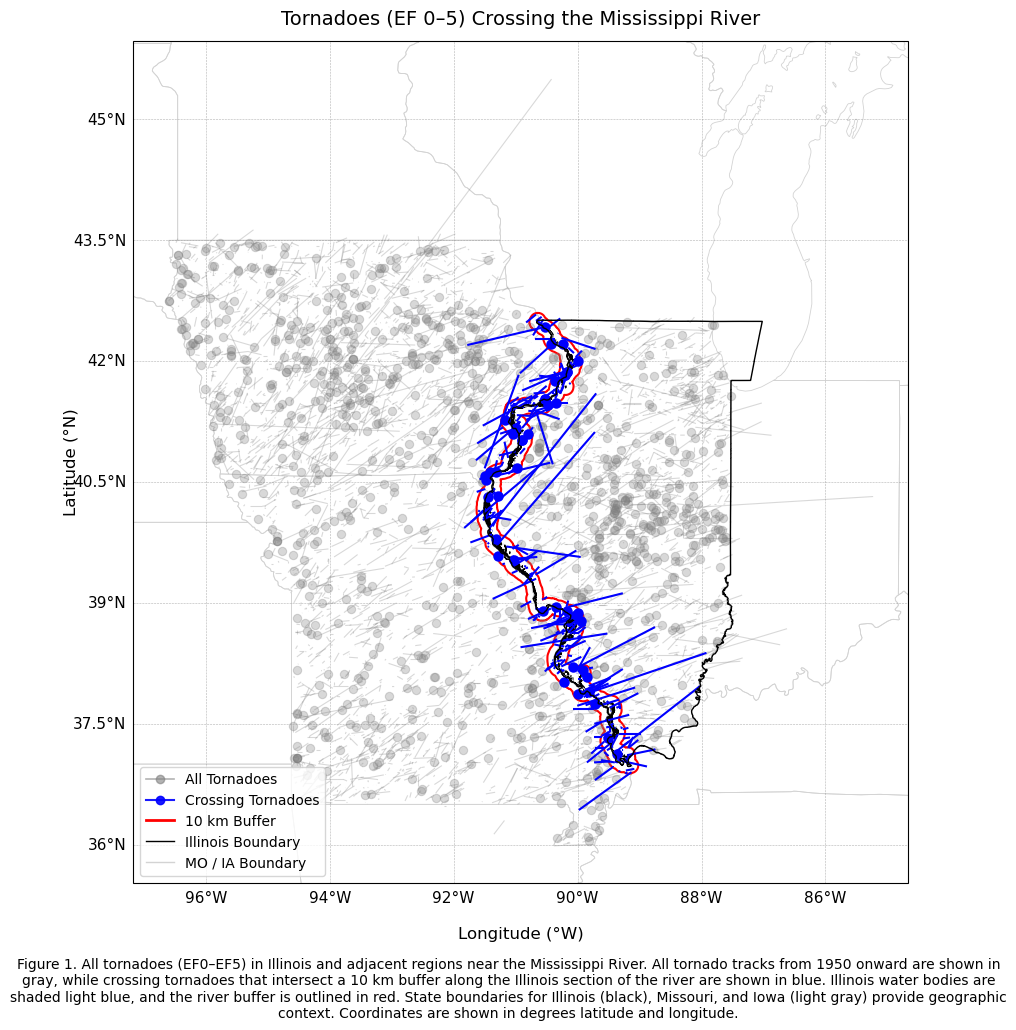

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reproject all layers to geographic (EPSG:4326)
tornado_geo = tornado_gdf.to_crs("EPSG:4326")
crossings_geo = crossings.to_crs("EPSG:4326")
water_il_geo = water_il.to_crs("EPSG:4326")
illinois_geo = illinois.to_crs("EPSG:4326")
river_buffer_geo = gpd.GeoSeries([river_buffer], crs=water_il.crs).to_crs("EPSG:4326")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 14), subplot_kw={'projection': ccrs.PlateCarree()})

# Add map background
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor='lightgray', linewidth=0.6)

# Plot layers
water_il_geo.plot(ax=ax, color='lightblue', edgecolor='k', transform=ccrs.PlateCarree(), zorder=1)
river_buffer_geo.boundary.plot(ax=ax, color='red', linewidth=1.5, transform=ccrs.PlateCarree(), label='10 km Buffer', zorder=2)
tornado_geo.plot(ax=ax, color='gray', linewidth=0.8, alpha=0.3, transform=ccrs.PlateCarree(), label='All Tornadoes', zorder=3)
crossings_geo.plot(ax=ax, color='blue', linewidth=1.5, transform=ccrs.PlateCarree(), label='Crossing Tornadoes', zorder=4)
illinois_geo.boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree(), zorder=5)

# Gridlines and coordinate labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Add axis labels manually
ax.text(0.5, -0.06, 'Longitude (°W)', va='center', ha='center', fontsize=12, transform=ax.transAxes)
ax.text(-0.08, 0.5, 'Latitude (°N)', va='center', ha='center', rotation='vertical', fontsize=12, transform=ax.transAxes)

# --- Custom legend handles (combined line + point) ---
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=1.2, marker='o', markersize=6, 
           label='All Tornadoes', alpha=0.6),
    Line2D([0], [0], color='blue', linewidth=1.5, marker='o', markersize=6, 
           label='Crossing Tornadoes', alpha=0.9),
    Line2D([0], [0], color='red', linewidth=2, label='10 km Buffer'),
    Line2D([0], [0], color='black', linewidth=1, label='Illinois Boundary'),
    Line2D([0], [0], color='lightgray', linewidth=1, label='MO / IA Boundary'),
]

# Add title and legend
ax.set_title("Tornadoes (EF 0–5) Crossing the Mississippi River", fontsize=14, pad=12)
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, frameon=True)

# Caption
caption = (
    "Figure 1. All tornadoes (EF0–EF5) in Illinois and adjacent regions near the Mississippi River. "
    "All tornado tracks from 1950 onward are shown in gray, while crossing tornadoes that intersect a 10 km buffer "
    "along the Illinois section of the river are shown in blue. Illinois water bodies are shaded light blue, "
    "and the river buffer is outlined in red. State boundaries for Illinois (black), Missouri, and Iowa (light gray) "
    "provide geographic context. Coordinates are shown in degrees latitude and longitude."
)
plt.figtext(0.5, 0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()

In [21]:
# -------------------------------------------------------------------
# --- Identify west-side, east-side, and crossing tornadoes ---
# UPDATED: NEAREST-POINT RIVER METHOD
# -------------------------------------------------------------------

from shapely.ops import nearest_points

# ------------------------------------------------
# 1. Start with tornadoes only (EF0–EF5)
# ------------------------------------------------
weak_tornadoes = tornado_gdf[
    tornado_gdf["mag"].isin([0, 1, 2, 3, 4, 5])
].copy()

# ------------------------------------------------
# 2. Tornadoes that physically cross/touch river
# (UNCHANGED)
# ------------------------------------------------
crossing_tornadoes = weak_tornadoes[
    weak_tornadoes.intersects(river_il_geom)
].copy()

# ------------------------------------------------
# 3. Tornadoes within/touching 10 km buffer
# but NOT touching/crossing river
# ------------------------------------------------
buffer_only = weak_tornadoes[
    weak_tornadoes.intersects(river_buffer) &
    (~weak_tornadoes.intersects(river_il_geom))
].copy()

# ------------------------------------------------
# 4. Representative point for side determination
# ------------------------------------------------
buffer_only["rep_point"] = (
    buffer_only.geometry.representative_point()
)

# ------------------------------------------------
# 5. Determine side relative to
# NEAREST LOCAL RIVER POSITION
# ------------------------------------------------
def assign_side(point_geom):

    # nearest point ON river
    nearest_river_pt = nearest_points(
        point_geom,
        river_il_geom
    )[1]

    # compare x-position relative to local river
    dx = point_geom.x - nearest_river_pt.x

    return "West" if dx < 0 else "East"

# Apply classification
buffer_only["side"] = (
    buffer_only["rep_point"]
    .apply(assign_side)
)

# ------------------------------------------------
# 6. Split into west/east groups
# ------------------------------------------------
west_side = buffer_only[
    buffer_only["side"] == "West"
].copy()

east_side = buffer_only[
    buffer_only["side"] == "East"
].copy()

# ------------------------------------------------
# 7. Print summary results
# ------------------------------------------------
print("\n--- Tornado Interaction Summary ---")

print(f"Total tornadoes: {len(weak_tornadoes)}")

print(
    "  • West-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(west_side)}"
)

print(
    "  • East-side "
    "(within/touching 10 km buffer, not touching river): "
    f"{len(east_side)}"
)

print(
    "  • Crossing/touching the river: "
    f"{len(crossing_tornadoes)}"
)

print(
    "  • Sum check: "
    f"{len(west_side) + len(east_side) + len(crossing_tornadoes)} "
    "(should equal 372)"
)


--- Tornado Interaction Summary ---
Total tornadoes: 5793
  • West-side (within/touching 10 km buffer, not touching river): 142
  • East-side (within/touching 10 km buffer, not touching river): 141
  • Crossing/touching the river: 89
  • Sum check: 372 (should equal 372)


In [22]:
# ================================================================
# Step 1: Define groups
# ================================================================

crossed = crossing_tornadoes.copy()   # test group (fixed)
west_side_all = west_side.copy()      # full west-side population
east_side_all = east_side.copy()      # full east-side population

# ================================================================
# Step 2: Print EF distributions
# ================================================================

def print_ef_counts(df, name):
    print(f"\n{name} EF distribution:")
    print(df["mag"].value_counts().sort_index())

print_ef_counts(crossed, "Crossed River")
print_ef_counts(west_side_all, "West Side (full)")
print_ef_counts(east_side_all, "East Side (full)")



Crossed River EF distribution:
mag
0    17
1    27
2    23
3    15
4     7
Name: count, dtype: int64

West Side (full) EF distribution:
mag
0    51
1    47
2    29
3    14
4     1
Name: count, dtype: int64

East Side (full) EF distribution:
mag
0    56
1    48
2    27
3     8
4     2
Name: count, dtype: int64


In [23]:
# ================================================================
# Step 3: Feasibility check (can we sample without replacement?)
# ================================================================

def check_sampling_feasibility(target, control, name):
    print(f"\nChecking feasibility for {name}...")
    ef_target = target["mag"].value_counts()
    ef_control = control["mag"].value_counts()

    for ef, count in ef_target.items():
        available = ef_control.get(ef, 0)
        if available < count:
            print(f"  EF{ef}: NOT enough samples (need {count}, have {available}) -> will sample WITH replacement")
        else:
            print(f"  EF{ef}: OK (need {count}, have {available})")

check_sampling_feasibility(crossed, west_side_all, "West Side")
check_sampling_feasibility(crossed, east_side_all, "East Side")



Checking feasibility for West Side...
  EF1: OK (need 27, have 47)
  EF2: OK (need 23, have 29)
  EF0: OK (need 17, have 51)
  EF3: NOT enough samples (need 15, have 14) -> will sample WITH replacement
  EF4: NOT enough samples (need 7, have 1) -> will sample WITH replacement

Checking feasibility for East Side...
  EF1: OK (need 27, have 48)
  EF2: OK (need 23, have 27)
  EF0: OK (need 17, have 56)
  EF3: NOT enough samples (need 15, have 8) -> will sample WITH replacement
  EF4: NOT enough samples (need 7, have 2) -> will sample WITH replacement


In [24]:
def sample_controls_by_intensity(target_df, control_df, ef_col="mag"):
    sampled = []
    ef_counts = target_df[ef_col].value_counts()

    for ef, count in ef_counts.items():
        subset = control_df[control_df[ef_col] == ef]

        # If not enough samples → sample with replacement
        replace_flag = len(subset) < count

        sampled_subset = subset.sample(n=count, replace=replace_flag)
        sampled.append(sampled_subset)

    return pd.concat(sampled)

In [25]:
# ================================================================
# Step 4: Intensity-matched sampling
# ================================================================

np.random.seed(42)

west_matched = sample_controls_by_intensity(crossed, west_side_all)
east_matched = sample_controls_by_intensity(crossed, east_side_all)

# ================================================================
# Step 5: Verify EF match
# ================================================================

print("\n--- EF MATCH VERIFICATION ---")

print("\nCrossed River:")
print(crossed["mag"].value_counts().sort_index())

print("\nWest Matched:")
print(west_matched["mag"].value_counts().sort_index())

print("\nEast Matched:")
print(east_matched["mag"].value_counts().sort_index())

print("\nSample sizes:")
print(f"  Crossed River: {len(crossed)}")
print(f"  West Matched:  {len(west_matched)}")
print(f"  East Matched:  {len(east_matched)}")


--- EF MATCH VERIFICATION ---

Crossed River:
mag
0    17
1    27
2    23
3    15
4     7
Name: count, dtype: int64

West Matched:
mag
0    17
1    27
2    23
3    15
4     7
Name: count, dtype: int64

East Matched:
mag
0    17
1    27
2    23
3    15
4     7
Name: count, dtype: int64

Sample sizes:
  Crossed River: 89
  West Matched:  89
  East Matched:  89



Total tornadoes (width matched, crossing-based): 267


/tmp/ipykernel_1346/3046139692.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




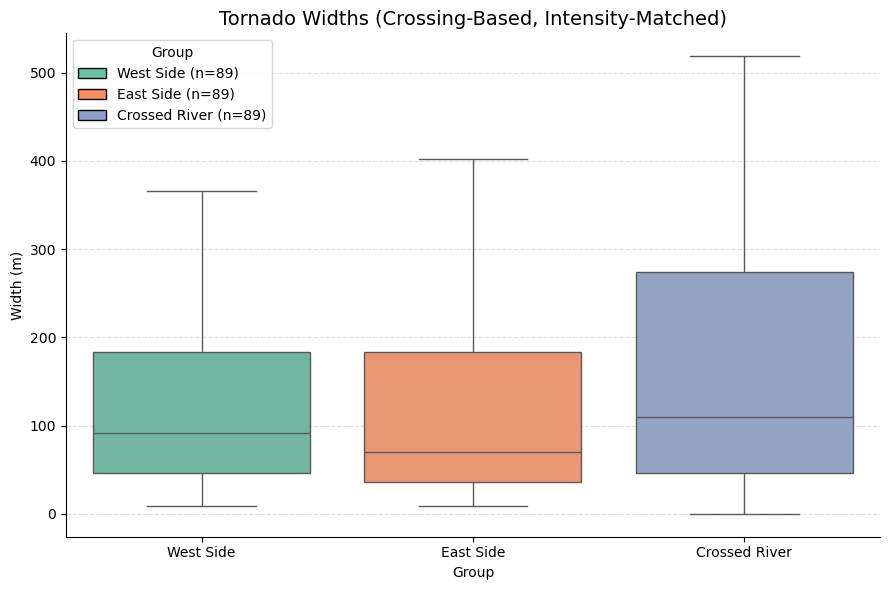

In [26]:
def prep_width(df, label):
    out = df[['wid']].copy()
    out['width_m'] = out['wid'] * 0.9144
    out['side_type'] = label
    return out

west_plot = prep_width(west_matched, "West Side")
east_plot = prep_width(east_matched, "East Side")
crossed_plot = prep_width(crossed, "Crossed River")

width_df = pd.concat([west_plot, east_plot, crossed_plot], ignore_index=True)

print("\nTotal tornadoes (width matched, crossing-based):", len(width_df))

# --- Boxplot ---
plt.figure(figsize=(9,6))
palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=width_df,
    x="side_type",
    y="width_m",
    palette=palette,
    showfliers=False
)

counts = width_df["side_type"].value_counts()

legend_elements = [
    Patch(facecolor=palette[i], edgecolor='black',
          label=f"{cat} (n={counts[cat]})")
    for i, cat in enumerate(['West Side', 'East Side', 'Crossed River'])
]

ax.legend(handles=legend_elements, loc='upper left', title="Group")

ax.set_title("Tornado Widths (Crossing-Based, Intensity-Matched)", fontsize=14)
ax.set_xlabel("Group")
ax.set_ylabel("Width (m)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

In [27]:
import itertools
from scipy.stats import kruskal

groups = width_df.groupby("side_type")["width_m"].apply(list)

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test (WIDTH, Crossing-Based)")
print("--------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

# --- Pairwise ---
pairs = list(itertools.combinations(groups.index, 2))

results = []
for a, b in pairs:
    stat, p_val = kruskal(groups[a], groups[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val
    })

pairwise_df = pd.DataFrame(results)

# --- Bonferroni correction --- (Optional)
n_tests = len(pairwise_df)
pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests
pairwise_df["Significant?"] = pairwise_df["p-value"] < 0.05
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Results (WIDTH, Crossing-Based):")
display(pairwise_df)


Kruskal-Wallis Test (WIDTH, Crossing-Based)
--------------------------------------------
H = 6.897
p-value = 0.031790

Pairwise Results (WIDTH, Crossing-Based):


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,Crossed River,East Side,6.085166,0.013632,0.040896,True,True
1,Crossed River,West Side,0.966774,0.325486,0.976458,False,False
2,East Side,West Side,3.307925,0.068947,0.206840,False,False


In [28]:
n_boot = 10000
np.random.seed(42)

p_values = []
H_values = []

# FULL populations
west_full = west_side_all.copy()
east_full = east_side_all.copy()

for i in range(n_boot):

    # --- EF-matched sampling relative to CROSSINGS ---
    west_sample = sample_controls_by_intensity(crossed, west_full)
    east_sample = sample_controls_by_intensity(crossed, east_full)

    df_boot = pd.concat([
        prep_width(west_sample, "West Side"),
        prep_width(east_sample, "East Side"),
        prep_width(crossed, "Crossed River")  # fixed
    ], ignore_index=True)

    # --- Consistent group ordering ---
    groups_boot = [
        df_boot[df_boot["side_type"] == g]["width_m"].values
        for g in ["West Side", "East Side", "Crossed River"]
    ]

    try:
        H_stat, p_boot = kruskal(*groups_boot)
        H_values.append(H_stat)
        p_values.append(p_boot)
    except:
        continue

p_values = np.array(p_values)
H_values = np.array(H_values)

# --- Summary ---
print("\nMonte Carlo Resampling Results (WIDTH, Crossing-Based)")
print("--------------------------------------------------------")
print(f"Valid iterations: {len(p_values)}")

print("\nP-value statistics:")
print(f"  Mean p-value:   {np.mean(p_values):.4f}")
print(f"  Median p-value: {np.median(p_values):.4f}")
print(f"  Std dev:        {np.std(p_values):.4f}")
print(f"  Fraction p < 0.05: {np.mean(p_values < 0.05):.4f}")

print("\nH-statistic statistics:")
print(f"  Mean H:   {np.mean(H_values):.3f}")
print(f"  Median H: {np.median(H_values):.3f}")
print(f"  Std dev:  {np.std(H_values):.3f}")


Monte Carlo Resampling Results (WIDTH, Crossing-Based)
--------------------------------------------------------
Valid iterations: 10000

P-value statistics:
  Mean p-value:   0.0466
  Median p-value: 0.0254
  Std dev:        0.0584
  Fraction p < 0.05: 0.6996

H-statistic statistics:
  Mean H:   7.662
  Median H: 7.344
  Std dev:  2.849



Total tornadoes (pathlength matched, crossing-based): 267


/tmp/ipykernel_1346/1655927630.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




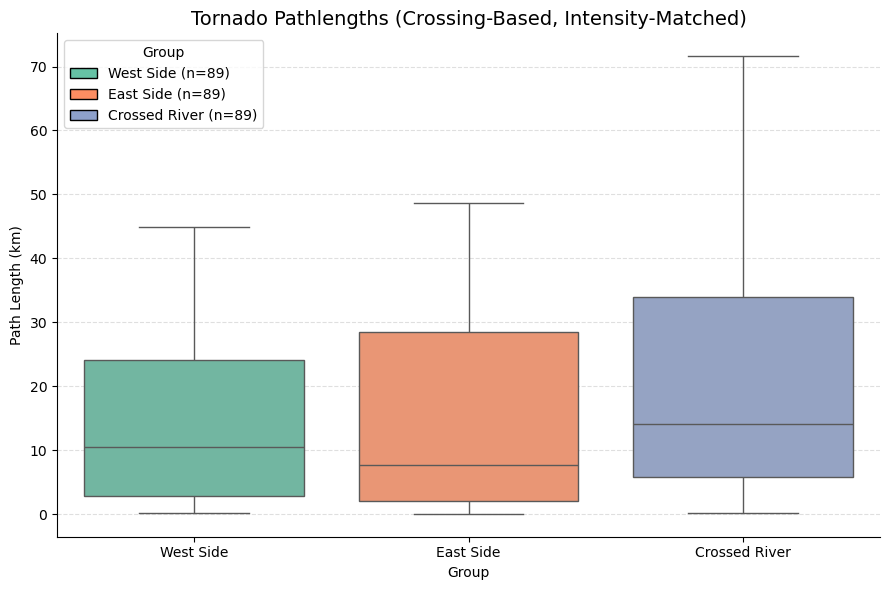

In [29]:
def prep_length(df, label):
    out = df[['len']].copy()
    out['len_km'] = out['len'] * 1.60934  # miles → km
    out['side_type'] = label
    return out

west_plot = prep_length(west_matched, "West Side")
east_plot = prep_length(east_matched, "East Side")
crossed_plot = prep_length(crossed, "Crossed River")

length_df = pd.concat([west_plot, east_plot, crossed_plot], ignore_index=True)

print("\nTotal tornadoes (pathlength matched, crossing-based):", len(length_df))

# --- Boxplot ---
plt.figure(figsize=(9,6))
palette = sns.color_palette("Set2", 3)

ax = sns.boxplot(
    data=length_df,
    x="side_type",
    y="len_km",
    palette=palette,
    showfliers=False
)

counts = length_df["side_type"].value_counts()

legend_elements = [
    Patch(facecolor=palette[i], edgecolor='black',
          label=f"{cat} (n={counts[cat]})")
    for i, cat in enumerate(['West Side', 'East Side', 'Crossed River'])
]

ax.legend(handles=legend_elements, loc='upper left', title="Group")

ax.set_title("Tornado Pathlengths (Crossing-Based, Intensity-Matched)", fontsize=14)
ax.set_xlabel("Group")
ax.set_ylabel("Path Length (km)")
ax.grid(axis='y', linestyle='--', alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

In [30]:
import itertools
from scipy.stats import kruskal

groups = length_df.groupby("side_type")["len_km"].apply(list)

H, p = kruskal(*groups)

print("\nKruskal-Wallis Test (PATHLENGTH, Crossing-Based)")
print("------------------------------------------------")
print(f"H = {H:.3f}")
print(f"p-value = {p:.6f}")

# --- Pairwise ---
pairs = list(itertools.combinations(groups.index, 2))

results = []
for a, b in pairs:
    stat, p_val = kruskal(groups[a], groups[b])
    results.append({
        "Group1": a,
        "Group2": b,
        "H": stat,
        "p-value": p_val
    })

pairwise_df = pd.DataFrame(results)

# --- Bonferroni correction --- (Optional)
n_tests = len(pairwise_df)
pairwise_df["Adj p-value (Bonferroni)"] = pairwise_df["p-value"] * n_tests
pairwise_df["Significant?"] = pairwise_df["p-value"] < 0.05
pairwise_df["Adj Significant?"] = pairwise_df["Adj p-value (Bonferroni)"] < 0.05

print("\nPairwise Results (PATHLENGTH, Crossing-Based):")
display(pairwise_df)


Kruskal-Wallis Test (PATHLENGTH, Crossing-Based)
------------------------------------------------
H = 9.522
p-value = 0.008557

Pairwise Results (PATHLENGTH, Crossing-Based):


,Group1,Group2,H,p-value,Adj p-value (Bonferroni),Significant?,Adj Significant?
0,Crossed River,East Side,8.575362,0.003407,0.010222,True,True
1,Crossed River,West Side,5.390377,0.020248,0.060744,True,False
2,East Side,West Side,0.292873,0.588385,1.765156,False,False


In [31]:
n_boot = 10000
np.random.seed(42)

p_values = []
H_values = []

# FULL populations
west_full = west_side_all.copy()
east_full = east_side_all.copy()

for i in range(n_boot):

    # --- EF-matched sampling relative to CROSSINGS ---
    west_sample = sample_controls_by_intensity(crossed, west_full)
    east_sample = sample_controls_by_intensity(crossed, east_full)

    df_boot = pd.concat([
        prep_length(west_sample, "West Side"),
        prep_length(east_sample, "East Side"),
        prep_length(crossed, "Crossed River")  # fixed
    ], ignore_index=True)

    # --- Consistent group order ---
    groups_boot = [
        df_boot[df_boot["side_type"] == g]["len_km"].values
        for g in ["West Side", "East Side", "Crossed River"]
    ]

    try:
        H_stat, p_boot = kruskal(*groups_boot)
        H_values.append(H_stat)
        p_values.append(p_boot)
    except:
        continue

p_values = np.array(p_values)
H_values = np.array(H_values)

# --- Summary ---
print("\nMonte Carlo Resampling Results (PATHLENGTH, Crossing-Based)")
print("------------------------------------------------------------")
print(f"Valid iterations: {len(p_values)}")

print("\nP-value statistics:")
print(f"  Mean p-value:   {np.mean(p_values):.4f}")
print(f"  Median p-value: {np.median(p_values):.4f}")
print(f"  Std dev:        {np.std(p_values):.4f}")
print(f"  Fraction p < 0.05: {np.mean(p_values < 0.05):.4f}")

print("\nH-statistic statistics:")
print(f"  Mean H:   {np.mean(H_values):.3f}")
print(f"  Median H: {np.median(H_values):.3f}")
print(f"  Std dev:  {np.std(H_values):.3f}")


Monte Carlo Resampling Results (PATHLENGTH, Crossing-Based)
------------------------------------------------------------
Valid iterations: 10000

P-value statistics:
  Mean p-value:   0.0169
  Median p-value: 0.0132
  Std dev:        0.0137
  Fraction p < 0.05: 0.9682

H-statistic statistics:
  Mean H:   8.747
  Median H: 8.662
  Std dev:  1.600


In [ ]:
#Next step will be to resample and compare crossed river tornadoes with west/east control populations (hopefully an even stronger signal). - I completed this on a new, separate Jupyter Notebook. 